In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])
df.columns=['Class label' , 'Alcohol' , 'Malic Acid']

In [14]:
df

,Class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

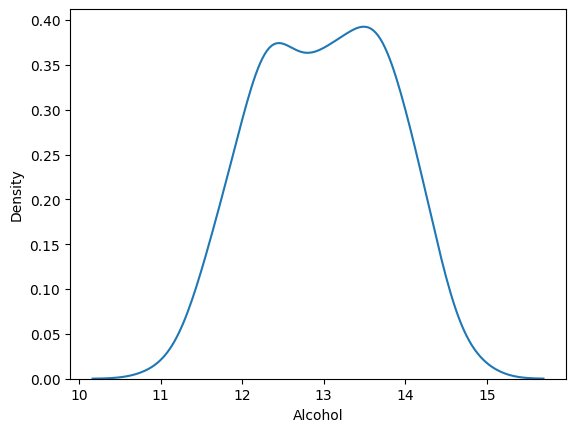

In [15]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

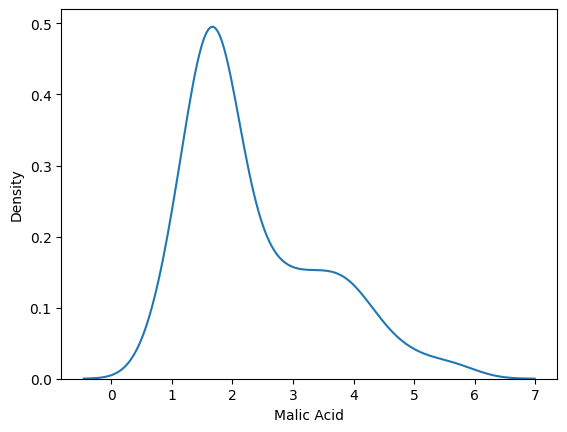

In [16]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

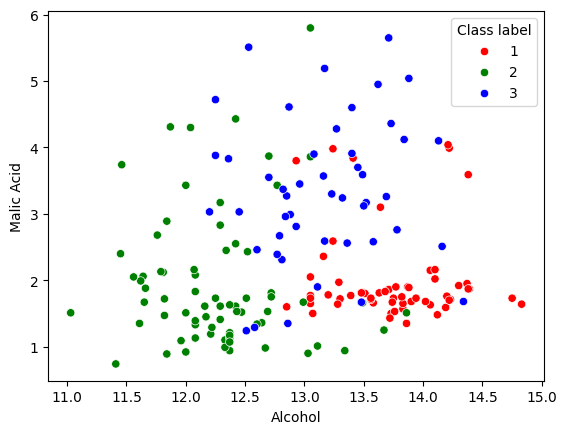

In [20]:
color_dict = {1:'Red' , 2:'Green' , 3:"Blue"}
sns.scatterplot(x = df['Alcohol'] ,y =  df['Malic Acid'] ,hue=df['Class label'] , palette=color_dict)

In [22]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(df.drop('Class label', axis=1), 
                                                       df['Class label'],
                                                       test_size=0.3,
                                                       random_state=0)

x_train.shape , x_test.shape

((124, 2), (54, 2))

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [25]:
x_train_scaled = pd.DataFrame(x_train_scaled , columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns=x_test.columns)

In [32]:
np.round(x_train_scaled.describe() , 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [31]:
x_train_scaled

,Alcohol,Malic Acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


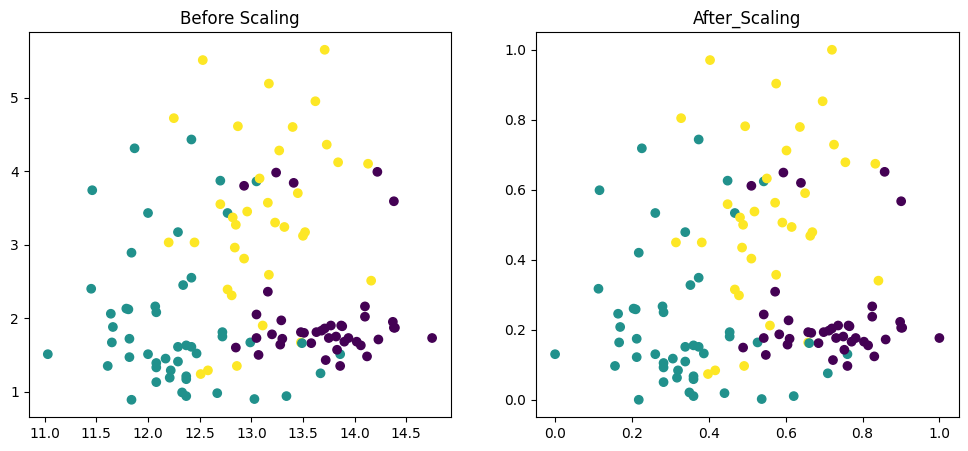

In [38]:
fig , (ax1 ,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(x_train['Alcohol'] , x_train['Malic Acid'] , c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaled['Alcohol'] , x_train_scaled['Malic Acid'] , c = y_train)
ax2.set_title("After_Scaling")

plt.show()

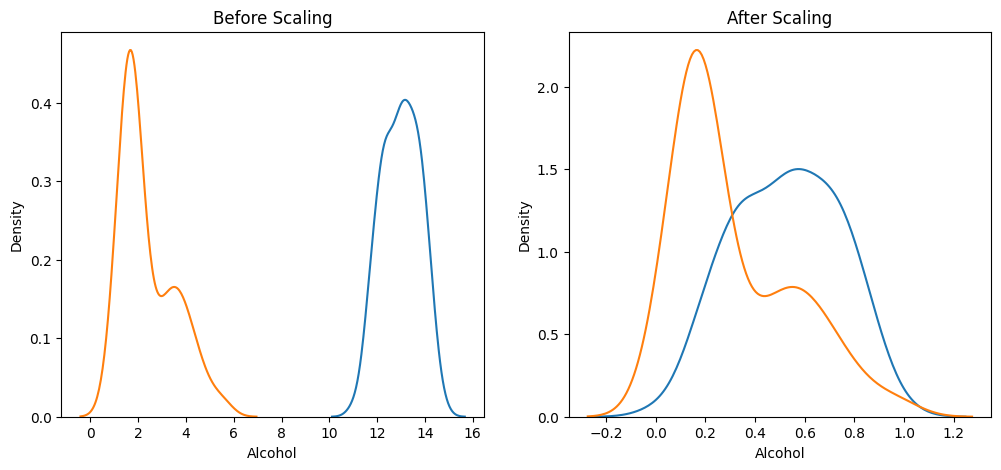

In [47]:
fig ,(ax1,ax2) = plt.subplots(ncols = 2 , figsize=(12,5))
#Before Scalling

ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Alcohol'] , ax=ax1 )
sns.kdeplot(x_train['Malic Acid'] , ax=ax1)

#After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Alcohol'] , ax=ax2)
sns.kdeplot(x_train_scaled['Malic Acid'] , ax=ax2)

plt.show()

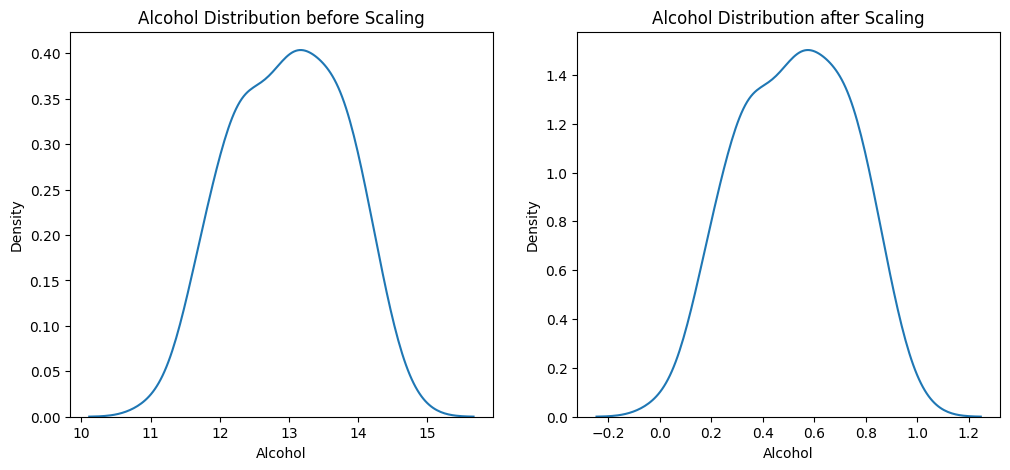

In [48]:
fig ,(ax1,ax2) = plt.subplots(ncols = 2 , figsize=(12,5))
#Before Scalling

ax1.set_title("Alcohol Distribution before Scaling")
sns.kdeplot(x_train['Alcohol'] , ax=ax1 )
 

#After Scaling
ax2.set_title("Alcohol Distribution after Scaling")
sns.kdeplot(x_train_scaled['Alcohol'] , ax=ax2)

plt.show()

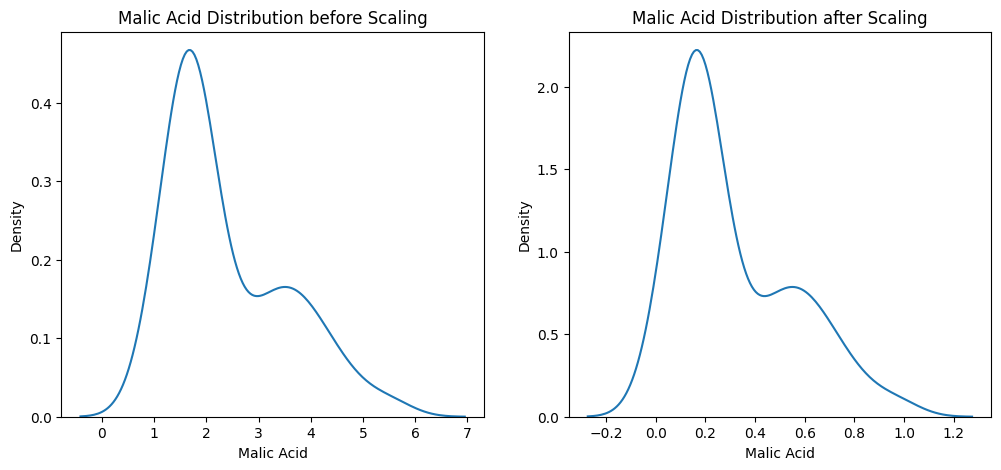

In [49]:
fig ,(ax1,ax2) = plt.subplots(ncols = 2 , figsize=(12,5))
#Before Scalling

ax1.set_title("Malic Acid Distribution before Scaling")
sns.kdeplot(x_train['Malic Acid'] , ax=ax1 )
 

#After Scaling
ax2.set_title("Malic Acid Distribution after Scaling")
sns.kdeplot(x_train_scaled['Malic Acid'] , ax=ax2)

plt.show()